# Step 4: Grid resolution

Does the numerical mixing shrink when the grid gets finer, and how fast? I ran the centred (2nd order) and WENO (5th order) tracer schemes at five grid spacings, dx = 2000, 1000, 500, 250 and 125 m, with dz = dx / 500 so all grids have the same cell shape (`simulations/run_step4.jl`; the 500 m runs come from steps 2 and 3). The coarsest grid has only 5 vertical levels, the finest 80. Everything else is as in the baseline, including the lateral viscosity of 1e-2 m^2/s.

I load the libraries and shared functions and list the runs.

In [1]:
%matplotlib inline

import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from mixing_tools import (DELTA_B, DEPTH, LENGTH, load_run, rpe_series, buoyancy_variance, front_positions,
                          front_speed, rpe_rate_at, density)

SPACINGS = [2000, 1000, 500, 250, 125]                 # dx (m); dz = dx / 500
RUN_NAMES = {"WENO, 5th order": {2000: "step4_weno5_dx2000", 1000: "step4_weno5_dx1000", 500: "step2_baseline_weno",
                                 250: "step4_weno5_dx250", 125: "step4_weno5_dx125"},
             "centred, 2nd order": {2000: "step4_centered2_dx2000", 1000: "step4_centered2_dx1000",
                                    500: "step3_tracer_centered2_wide_limit", 250: "step4_centered2_dx250",
                                    125: "step4_centered2_dx125"}}
COLORS = {"WENO, 5th order": "tab:blue", "centred, 2nd order": "tab:red"}
NU_H = 1e-2                                           # lateral viscosity in all these runs (m^2/s)
U_SCALE = 0.5 * np.sqrt(DELTA_B * DEPTH)             # front speed scale for the grid Reynolds number (m/s)
MARGIN = 0.05                                         # kg/m^3: a cell is 'mixed' or 'outside' beyond this margin
FIT_START, FIT_END = 3 * 3600, 15 * 3600
FIG_DIR = "../figures"
DATA_DIR = "../data"

I compute the same measures as in step 3 for every run: RPE change and dRPE/dt at 17 h, variance change, overshoot, front speed, the fraction of mixed cells and of cells outside the starting range, and the run time.

In [2]:
rows = []
series = {}
for scheme, names in RUN_NAMES.items():
    for dx in SPACINGS:
        ds, log, info = load_run(names[dx])
        times = ds.time.values
        rpe = rpe_series(ds)
        variance = buoyancy_variance(ds)
        right, left = front_positions(ds)
        rho_end = density(ds["b"].sel(time=17 * 3600, method="nearest").values)
        series[(scheme, dx)] = (times, rpe, ds)
        rows.append({"scheme": scheme, "dx_m": dx, "dz_m": dx / 500, "Nx": int(info["Nx"]), "Nz": int(info["Nz"]),
                     "grid_reynolds": U_SCALE * dx / NU_H,
                     "rpe_change_17h": (rpe[-1] - rpe[0]) / rpe[0],
                     "drpe_dt_17h_W_m2": rpe_rate_at(times, rpe, 17 * 3600, 3600) / LENGTH,
                     "rpe_smallest_step": np.min(np.diff(rpe)) / rpe[0],
                     "variance_change_17h": (variance[-1] - variance[0]) / variance[0],
                     "overshoot": max(log["b_max"].max() - DELTA_B, 0) / DELTA_B,
                     "undershoot": max(-log["b_min"].min(), 0) / DELTA_B,
                     "mixed_fraction": np.mean((rho_end > density(DELTA_B) + MARGIN) & (rho_end < density(0.0) - MARGIN)),
                     "outside_fraction": np.mean((rho_end > density(0.0) + MARGIN) | (rho_end < density(DELTA_B) - MARGIN)),
                     "front_speed_m_s": front_speed(times, right, FIT_START, FIT_END),
                     "status": info["status"], "iterations": int(info["iterations"]), "wall_time_s": float(info["wall_time_s"])})
table = pd.DataFrame(rows)
table.to_csv(os.path.join(DATA_DIR, "step4_resolution.csv"), index=False)
pd.set_option("display.width", 200)
print(table[["scheme", "dx_m", "Nx", "Nz", "grid_reynolds", "rpe_change_17h", "drpe_dt_17h_W_m2", "variance_change_17h",
             "overshoot", "mixed_fraction", "outside_fraction", "front_speed_m_s", "iterations", "wall_time_s"]].to_string(index=False))
print("all runs completed:", all(table["status"] == "completed"))

            scheme  dx_m  Nx  Nz  grid_reynolds  rpe_change_17h  drpe_dt_17h_W_m2  variance_change_17h  overshoot  mixed_fraction  outside_fraction  front_speed_m_s  iterations  wall_time_s
   WENO, 5th order  2000  32   5   99045.444115        0.000051          0.004720            -0.238215   0.000036        0.612500          0.000000         0.481200         705         4.60
   WENO, 5th order  1000  64  10   49522.722058        0.000044          0.002083            -0.186891   0.000130        0.409375          0.000000         0.482794         905         4.54
   WENO, 5th order   500 128  20   24761.361029        0.000035          0.001890            -0.185590   0.000211        0.359375          0.000000         0.479298        1907        21.26
   WENO, 5th order   250 256  40   12380.680514        0.000033          0.001855            -0.184602   0.000288        0.340039          0.000000         0.481380        6151        28.02
   WENO, 5th order   125 512  80    6190.340257   

Buoyancy after 17 hours on every grid, WENO on the left and centred on the right, on the same colour scale.

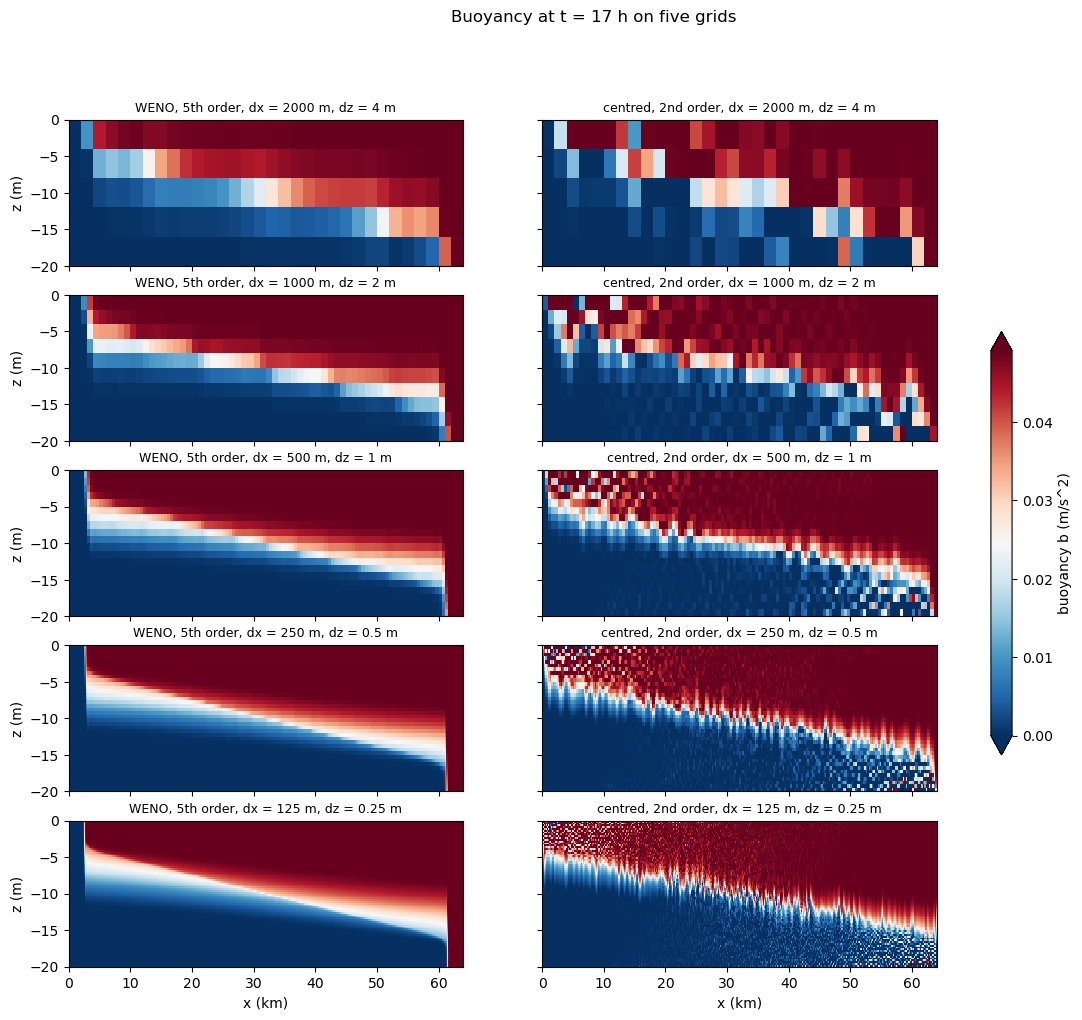

In [3]:
fig, axes = plt.subplots(len(SPACINGS), 2, figsize=(14, 11), sharex=True, sharey=True)
for col, scheme in enumerate(RUN_NAMES):
    for row, dx in enumerate(SPACINGS):
        ds = series[(scheme, dx)][2]
        snapshot = ds["b"].sel(time=17 * 3600, method="nearest")
        ax = axes[row, col]
        mesh = ax.pcolormesh(ds.x_caa / 1e3, ds.z_aac, snapshot, cmap="RdBu_r", vmin=0, vmax=DELTA_B, shading="nearest")
        ax.set_title(f"{scheme}, dx = {dx} m, dz = {dx / 500:g} m", fontsize=9)
        if col == 0:
            ax.set_ylabel("z (m)")
for ax in axes[-1]:
    ax.set_xlabel("x (km)")
fig.colorbar(mesh, ax=axes, label="buoyancy b (m/s^2)", shrink=0.5, extend="both")
fig.suptitle("Buoyancy at t = 17 h on five grids")
fig.savefig(os.path.join(FIG_DIR, "04_resolution_snapshots.png"), dpi=150, bbox_inches="tight")
plt.show()

How fast does the WENO mixing shrink? On log-log axes, a straight line with slope p means the RPE change goes like dx^p. For the centred scheme the RPE falls (the anti-diffusion of step 3), so it cannot be used; instead I show its overshoots, which are the main problem with that scheme.

WENO: RPE change at 17 h ~ dx^0.18 (between neighbouring grids: [0.05 0.09 0.31 0.22]); dRPE/dt at 17 h ~ dx^0.29
WENO: from dx = 2000 m to 125 m (16 times finer) the RPE change falls by a factor 1.60
centred: overshoot ~ dx^-0.68, from 0.81 (2000 m) to 5.85 (125 m) buoyancy differences


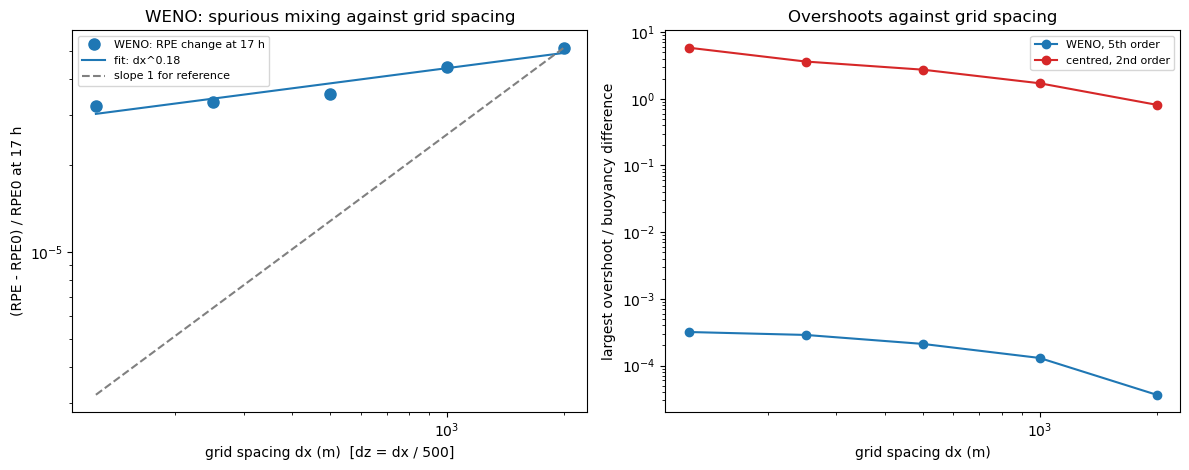

In [4]:
weno = table[table["scheme"] == "WENO, 5th order"].sort_values("dx_m")
cent = table[table["scheme"] == "centred, 2nd order"].sort_values("dx_m")
dx = weno["dx_m"].values
p_rpe, c_rpe = np.polyfit(np.log(dx), np.log(weno["rpe_change_17h"].values), 1)
p_rate, c_rate = np.polyfit(np.log(dx), np.log(weno["drpe_dt_17h_W_m2"].values), 1)
pairwise = np.diff(np.log(weno["rpe_change_17h"].values)) / np.diff(np.log(dx))
print(f"WENO: RPE change at 17 h ~ dx^{p_rpe:.2f} (between neighbouring grids: {np.round(pairwise, 2)}); "
      f"dRPE/dt at 17 h ~ dx^{p_rate:.2f}")
print(f"WENO: from dx = 2000 m to 125 m (16 times finer) the RPE change falls by a factor "
      f"{weno['rpe_change_17h'].values[-1] / weno['rpe_change_17h'].values[0]:.2f}")
p_over, c_over = np.polyfit(np.log(cent["dx_m"].values), np.log(cent["overshoot"].values), 1)
print(f"centred: overshoot ~ dx^{p_over:.2f}, from {cent['overshoot'].values[-1]:.2f} (2000 m) "
      f"to {cent['overshoot'].values[0]:.2f} (125 m) buoyancy differences")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
ax = axes[0]
ax.loglog(dx, weno["rpe_change_17h"], "o", color=COLORS["WENO, 5th order"], ms=8, label="WENO: RPE change at 17 h")
ax.loglog(dx, np.exp(c_rpe) * dx ** p_rpe, color=COLORS["WENO, 5th order"], label=f"fit: dx^{p_rpe:.2f}")
ax.loglog(dx, weno["rpe_change_17h"].values[-1] * (dx / dx[-1]), color="0.5", ls="--", label="slope 1 for reference")
ax.set_xlabel("grid spacing dx (m)  [dz = dx / 500]")
ax.set_ylabel("(RPE - RPE0) / RPE0 at 17 h")
ax.set_title("WENO: spurious mixing against grid spacing")
ax.legend(fontsize=8)
ax = axes[1]
for scheme, sub in [("WENO, 5th order", weno), ("centred, 2nd order", cent)]:
    ax.loglog(sub["dx_m"], sub["overshoot"], "o-", color=COLORS[scheme], label=scheme)
ax.set_xlabel("grid spacing dx (m)")
ax.set_ylabel("largest overshoot / buoyancy difference")
ax.set_title("Overshoots against grid spacing")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "04_resolution_convergence.png"), dpi=150)
plt.show()

The WENO RPE against time on all five grids.

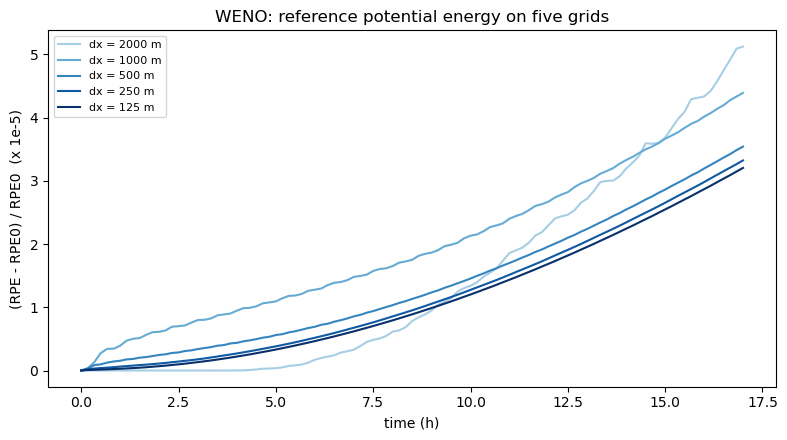

In [5]:
fig, ax = plt.subplots(figsize=(8, 4.5))
shades = plt.cm.Blues(np.linspace(0.35, 1.0, len(SPACINGS)))
for dx_value, shade in zip(SPACINGS, shades):
    times, rpe, ds = series[("WENO, 5th order", dx_value)]
    ax.plot(times / 3600, (rpe - rpe[0]) / rpe[0] * 1e5, color=shade, label=f"dx = {dx_value} m")
ax.set_xlabel("time (h)")
ax.set_ylabel("(RPE - RPE0) / RPE0  (x 1e-5)")
ax.set_title("WENO: reference potential energy on five grids")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "04_resolution_rpe_time.png"), dpi=150)
plt.show()

Why does the WENO mixing shrink so slowly? In all these runs the lateral viscosity is 1e-2 m^2/s, so the grid Reynolds number U dx / nu (with U = 0.495 m/s) is between 6200 (125 m) and 99000 (2000 m), always far above 100. Ilicak et al. (2012, Fig. 6 and Section 3.4) found that in this regime the spurious mixing is "high and steady (capped)": "changing horizontal grid spacing or viscosity does not reduce the spurious mixing in this regime", presumably because grid-scale noise in the velocity keeps stirring the interface. Step 5 tests the grid Reynolds number directly.

In [6]:
print(weno[["dx_m", "grid_reynolds", "rpe_change_17h", "mixed_fraction"]].to_string(index=False))

 dx_m  grid_reynolds  rpe_change_17h  mixed_fraction
  125    6190.340257        0.000032        0.336084
  250   12380.680514        0.000033        0.340039
  500   24761.361029        0.000035        0.359375
 1000   49522.722058        0.000044        0.409375
 2000   99045.444115        0.000051        0.612500
